## Part 1 - Data Exploraty Analysis

This notebook focuses on examing the raw dataset containing daily historical prices of notable stocks of Big Tech companies in NASDAQ, including NVDA (NVIDIA), GOOGL (Alphabet Inc.), MSFT (Microsoft), MU (Micron Technology),  AAPL (Apple). The goal is to identify a specific timeframe suitable for further analysis and prediction. 
> **INPUT**: 

> **OUTPUT**: 

### 1. INITIALIZATION

In [22]:
import sys
from pathlib import Path

# project root = parent of notebooks/
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import yfinance as yf
import src.data.loaders as loaders

### 2. LOAD DATASET AND CLEANING
The dataset we are going to load and explore is the historical records of daily stock prices of selected companies, sourced from Yahoo Finance library. 
At first, we load the complete dataset spanning for 10 years from 2006 up until the time of creating this script. 

> **fetch_nasdaq function** 
- fetch data
- convert String date format to pd_datetime for easy processing
- convert date to index
- sort_index: For easy slicing, rolling window cross validation


In [54]:
NVDA_df = loaders.fetch_nasdaq("NVDA", "2006-01-01", "2026-03-25")
MSFT_df = loaders.fetch_nasdaq("MSFT", "2006-01-01", "2026-03-25")
GOOGL_df = loaders.fetch_nasdaq("GOOGL", "2006-01-01", "2026-03-25")
AAPL_df = loaders.fetch_nasdaq("AAPL", "2006-01-01", "2026-03-25")
MU_df = loaders.fetch_nasdaq("MU", "2006-01-01", "2026-03-25")
AMZN_df = loaders.fetch_nasdaq("AMZN", "2006-01-01", "2026-03-25")
QCOM_df = loaders.fetch_nasdaq("QCOM", "2006-01-01", "2026-03-25")
NFLX_df = loaders.fetch_nasdaq("NFLX", "2006-01-01", "2026-03-25")
META_df = loaders.fetch_nasdaq("META", "2006-01-01", "2026-03-25")



In [50]:
# Check data shape
print(NVDA_df.shape)
print(MSFT_df.shape)
print(GOOGL_df.shape)  
print(AAPL_df.shape)
print(MU_df.shape)
print(AMZN_df.shape)
print(QCOM_df.shape)
print(NFLX_df.shape)
print(META_df.shape)


(5087, 6)
(5087, 6)
(5087, 6)
(5087, 6)
(5087, 6)
(5087, 6)
(5087, 6)
(5087, 6)
(3481, 6)


In [55]:
# Check data head
print(NVDA_df.head())
print(MSFT_df.head())
print(GOOGL_df.head())
print(AAPL_df.head())
print(MU_df.head())
print(AMZN_df.head())
print(QCOM_df.head())
print(NFLX_df.head())
print(META_df.head())



                open      high       low     close  adj_close     volume
date                                                                    
2006-01-03  0.306417  0.320833  0.305417  0.318500   0.291996  472812000
2006-01-04  0.320917  0.327917  0.317583  0.327417   0.300171  510072000
2006-01-05  0.327500  0.335417  0.326917  0.334833   0.306970  646092000
2006-01-06  0.338667  0.341583  0.325417  0.340333   0.312012  623388000
2006-01-09  0.340167  0.351667  0.339417  0.349833   0.320722  560484000
                 open       high    low      close  adj_close     volume
date                                                                    
2006-01-03  26.250000  27.000000  26.10  26.840000  18.672441   79973000
2006-01-04  26.770000  27.080000  26.77  26.969999  18.762880   57975600
2006-01-05  26.959999  27.129999  26.91  26.990000  18.776793   48245500
2006-01-06  26.889999  27.000000  26.49  26.910000  18.721146  100963000
2006-01-09  26.930000  27.070000  26.76  26.860001 

In [ ]:
# Check data types
print(NVDA_df.dtypes)
print(MSFT_df.dtypes)
print(GOOGL_df.dtypes)
print(AAPL_df.dtypes)
print(MU_df.dtypes)


open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object
open         float64

In [27]:
# Check the date as index
print(NVDA_df.index.name)  # date
print(NVDA_df.index.dtype) # datetime64[ns]
print(NVDA_df.index.is_unique) # No duplicates
print(NVDA_df.index.is_monotonic_increasing) # Sorted


date
datetime64[s]
True
True


### 3. EXPLORE DATASET

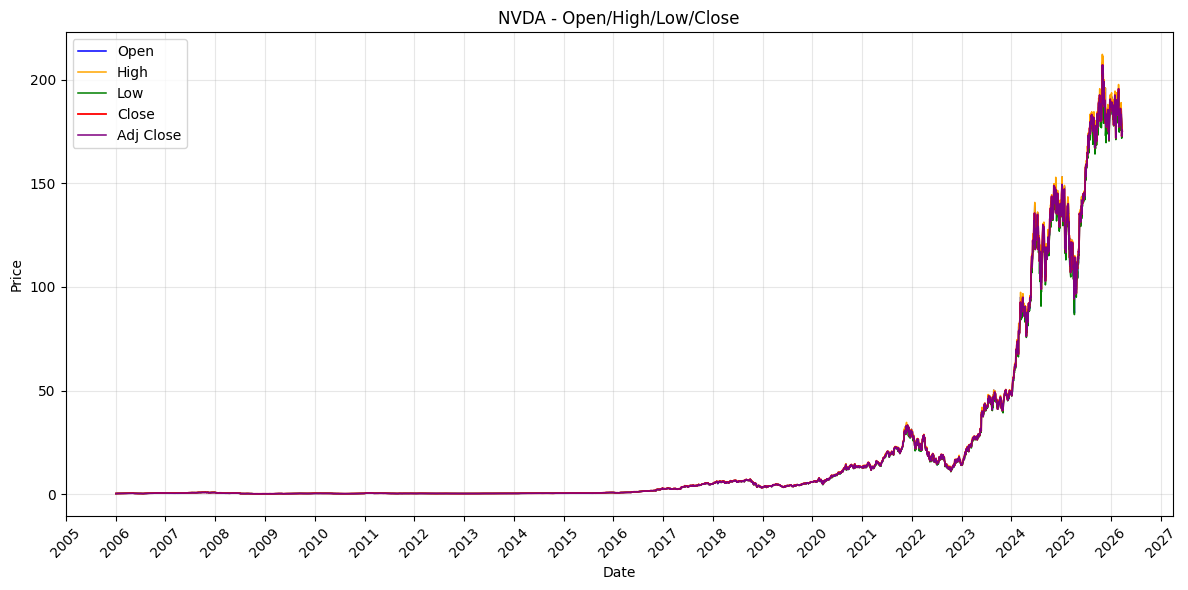

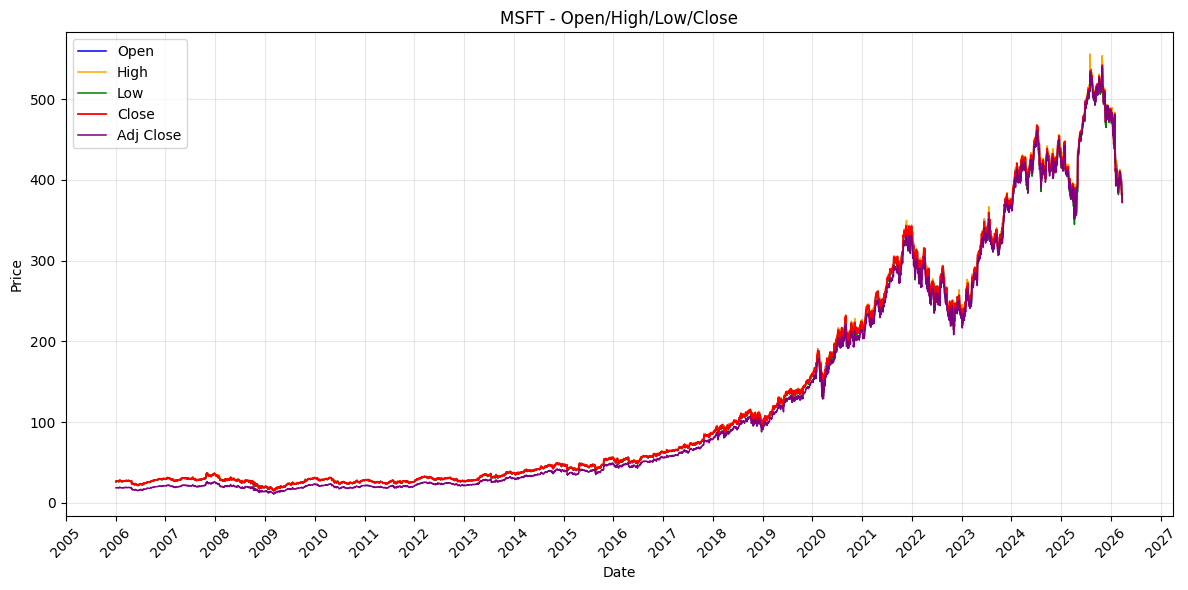

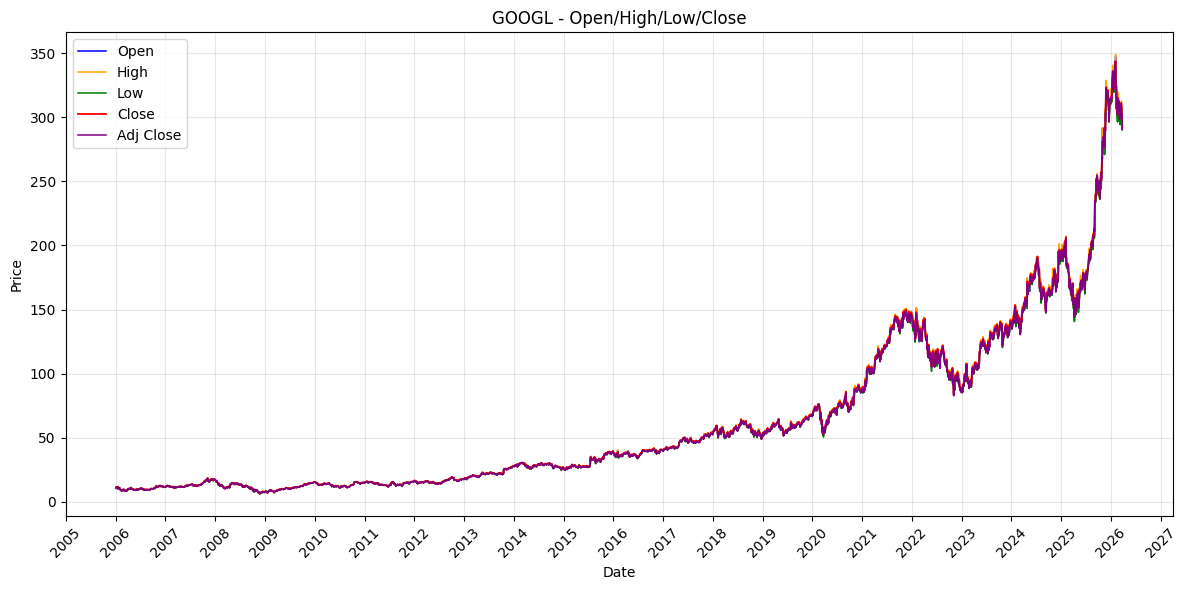

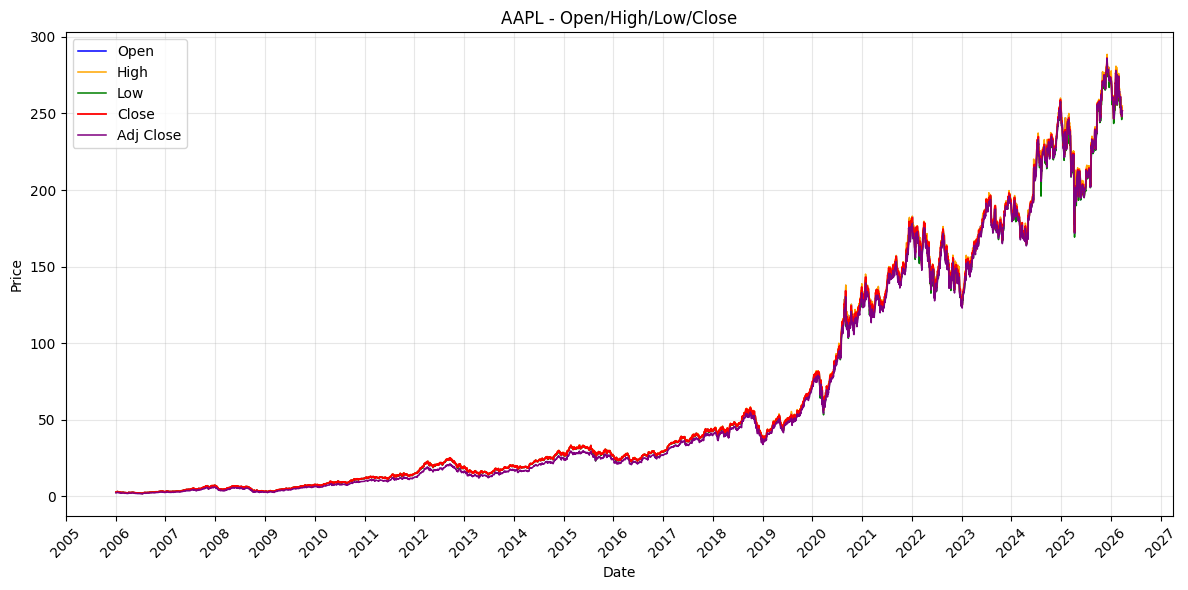

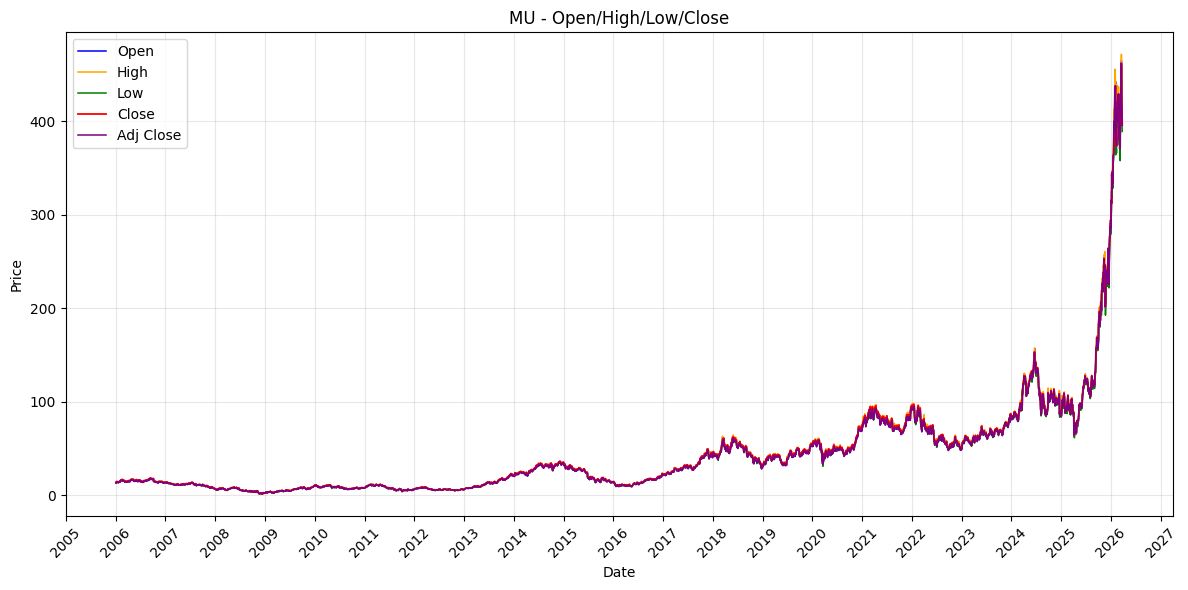

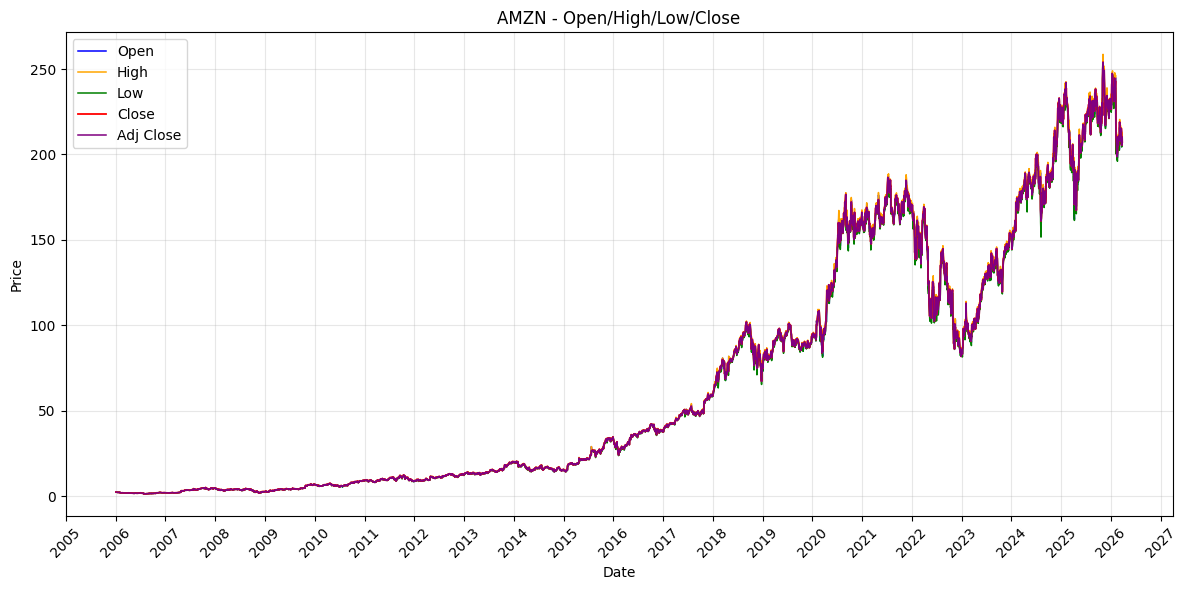

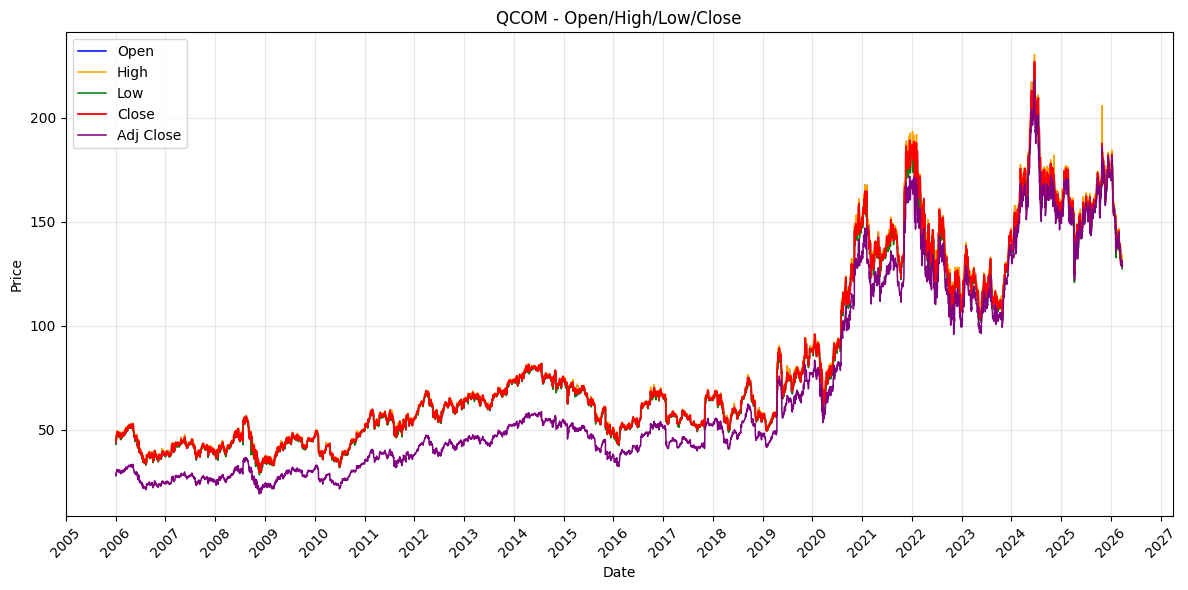

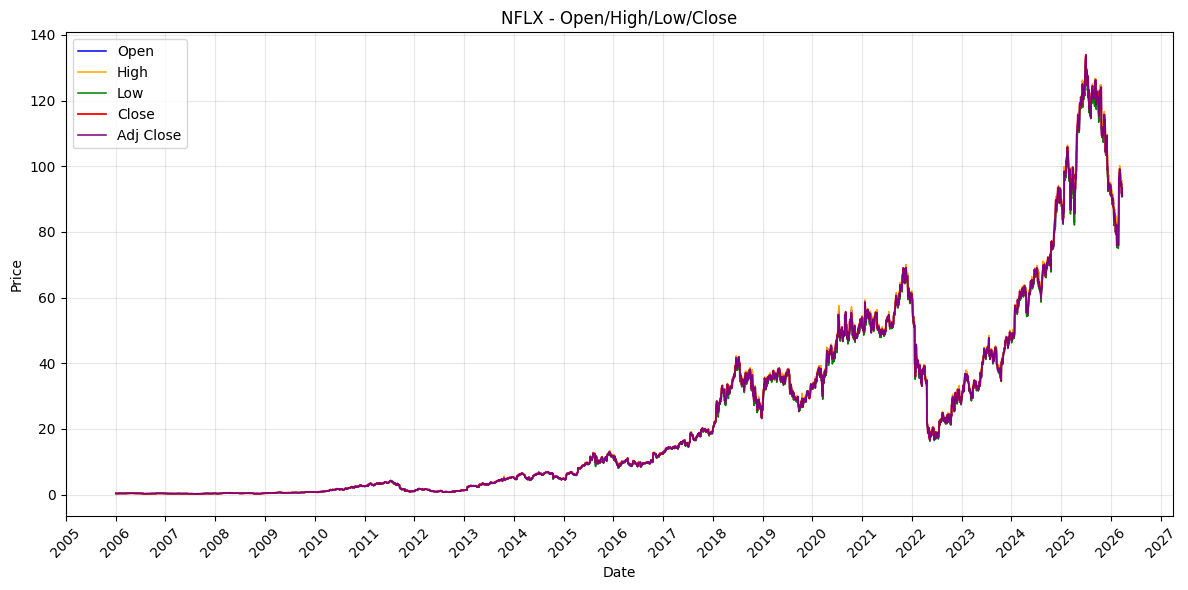

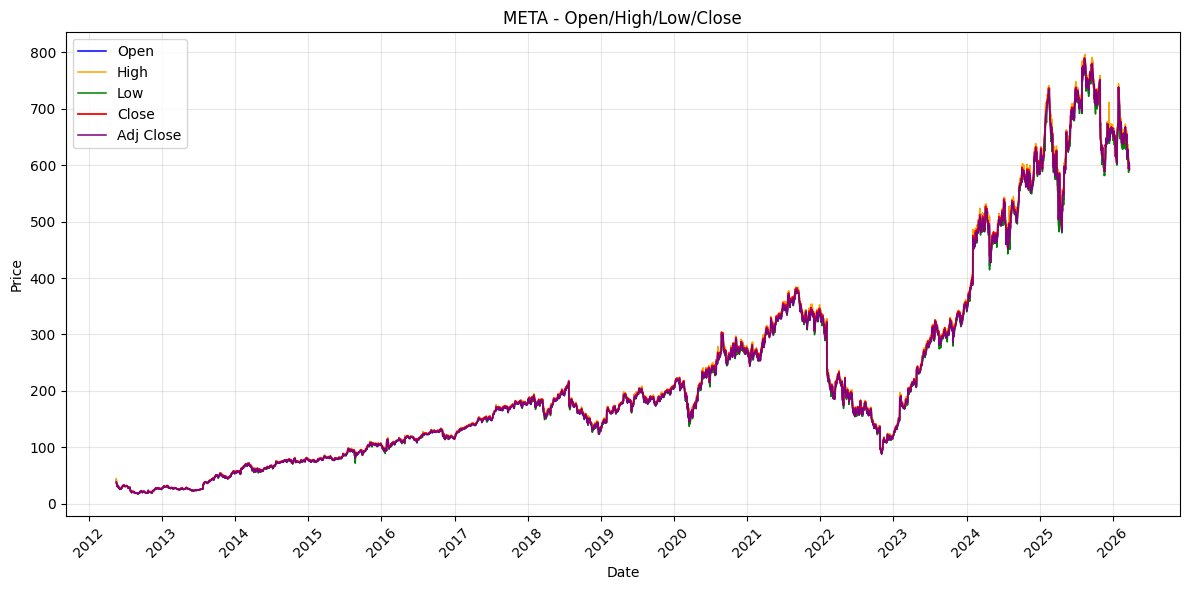

In [56]:
import matplotlib.dates as mdates

def plot_ohlc_one_graph(df, ticker):
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df.index, df["open"],  label="Open",  color="blue",   linewidth=1.1)
    ax.plot(df.index, df["high"],  label="High",  color="orange", linewidth=1.1)
    ax.plot(df.index, df["low"],   label="Low",   color="green",  linewidth=1.1)
    ax.plot(df.index, df["close"], label="Close", color="red",    linewidth=1.3)
    ax.plot(df.index, df["adj_close"], label="Adj Close", color="purple", linewidth=1.1)

    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)

    ax.set_title(f"{ticker} - Open/High/Low/Close")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_ohlc_one_graph(NVDA_df, "NVDA")
plot_ohlc_one_graph(MSFT_df, "MSFT")
plot_ohlc_one_graph(GOOGL_df, "GOOGL")
plot_ohlc_one_graph(AAPL_df, "AAPL")
plot_ohlc_one_graph(MU_df, "MU")
plot_ohlc_one_graph(AMZN_df, "AMZN")
plot_ohlc_one_graph(QCOM_df, "QCOM")
plot_ohlc_one_graph(NFLX_df, "NFLX")
plot_ohlc_one_graph(META_df, "META")


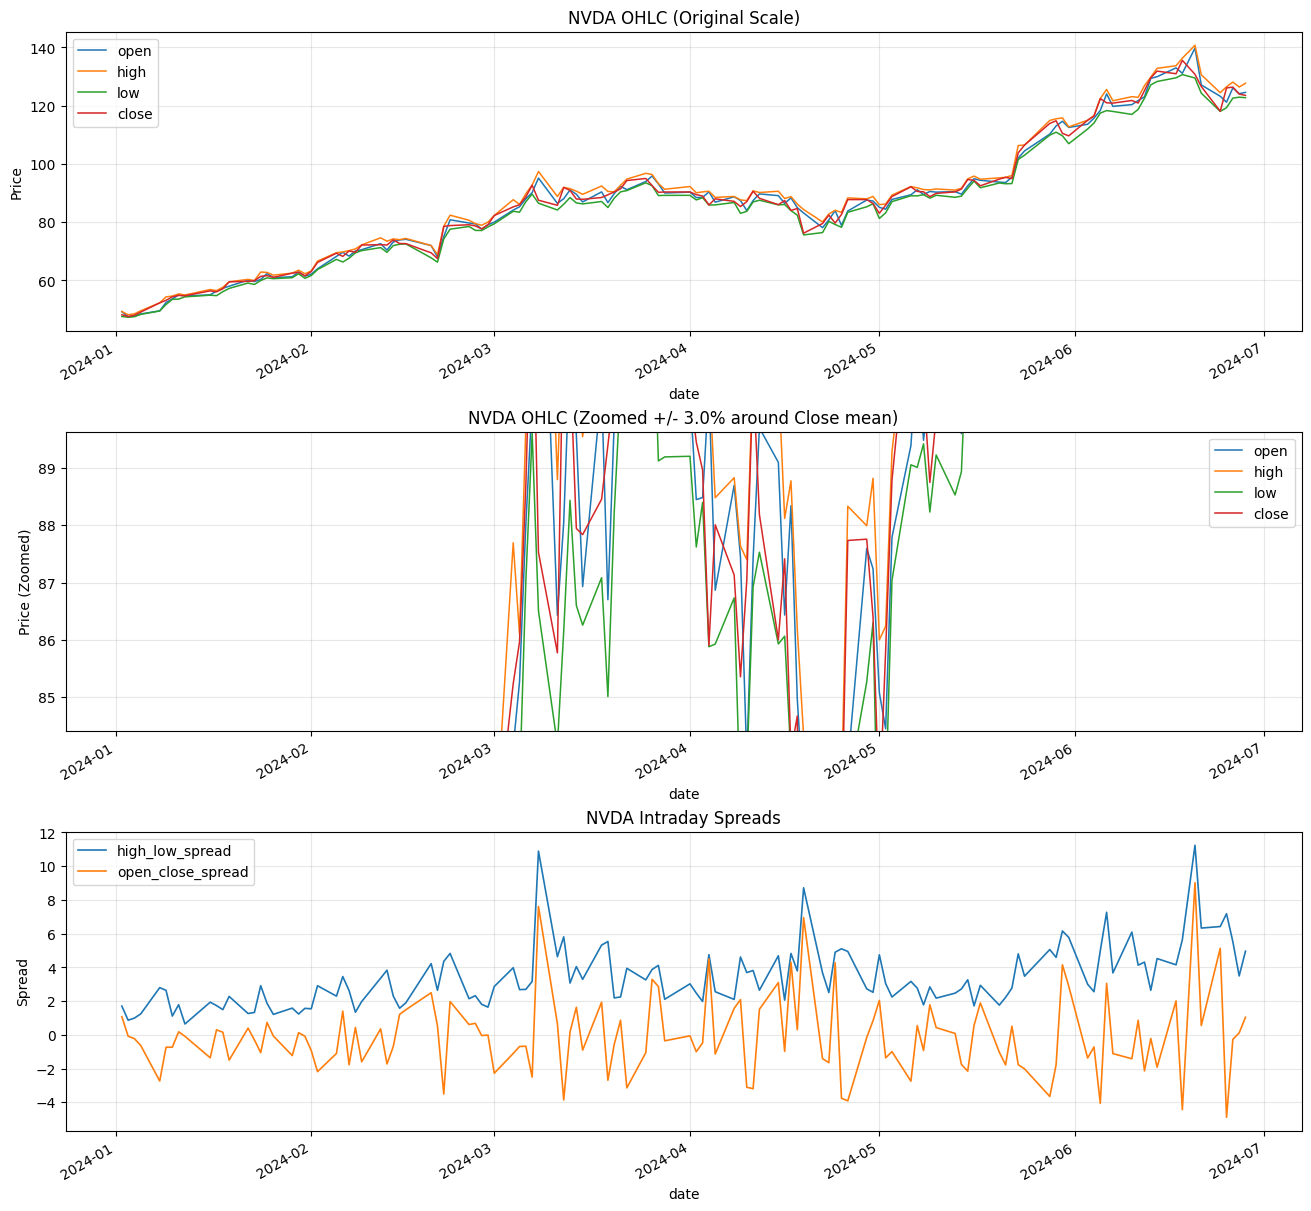

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_ohlc_eda(df, ticker="NVDA", start="2024-01-01", end="2024-06-30", zoom_pct=0.03):
    cols = ["open", "high", "low", "close"]
    d = df.loc[start:end, cols].copy()

    fig, axes = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

    # 1) Original OHLC
    d.plot(ax=axes[0], lw=1.1)
    axes[0].set_title(f"{ticker} OHLC (Original Scale)")
    axes[0].set_ylabel("Price")
    axes[0].grid(alpha=0.3)

    # 2) Zoomed Y-axis around close mean
    d.plot(ax=axes[1], lw=1.1)
    center = d["close"].mean()
    band = center * zoom_pct
    axes[1].set_ylim(center - band, center + band)
    axes[1].set_title(f"{ticker} OHLC (Zoomed +/- {zoom_pct*100:.1f}% around Close mean)")
    axes[1].set_ylabel("Price (Zoomed)")
    axes[1].grid(alpha=0.3)

    # 3) Relative spreads (differences)
    spread = pd.DataFrame(index=d.index)
    spread["high_low_spread"] = d["high"] - d["low"]
    spread["open_close_spread"] = d["open"] - d["close"]
    spread.plot(ax=axes[2], lw=1.2)
    axes[2].set_title(f"{ticker} Intraday Spreads")
    axes[2].set_ylabel("Spread")
    axes[2].grid(alpha=0.3)

    plt.show()

plot_ohlc_eda(NVDA_df, ticker="NVDA", start="2024-01-01", end="2024-06-30", zoom_pct=0.03)

# Example:
# plot_ohlc_eda(NVDA_df, ticker="NVDA", start="2024-01-01", end="2024-06-30", zoom_pct=0.03)

> **Comment**: Currently, there are no distinct differences between Open, Close, High, Low, Adjusted Close. 

> **Selected time frame**: The above charts show dynamic movements taking place around the start of 2016 in the tech industry in Nasdaq, whereas the prior time saw little activites. This indicates that old historical data before 2016 might not be relevant to the current market patterns. Subsequently, we will concentrate our model on the 10-year time span, as it is expected to provide more accurate insights for predicting future trends.

>**Backup**: One backup plan is to have 5-year time horizon only. 

In [57]:
NVDA_df = loaders.fetch_nasdaq("NVDA", "2016-01-01", "2026-03-25")
MSFT_df = loaders.fetch_nasdaq("MSFT", "2016-01-01", "2026-03-25")
GOOGL_df = loaders.fetch_nasdaq("GOOGL", "2016-01-01", "2026-03-25")
AAPL_df = loaders.fetch_nasdaq("AAPL", "2016-01-01", "2026-03-25")
MU_df = loaders.fetch_nasdaq("MU", "2016-01-01", "2026-03-25")
AMZN_df = loaders.fetch_nasdaq("AMZN", "2016-01-01", "2026-03-25")
META_df = loaders.fetch_nasdaq("META", "2016-01-01", "2026-03-25")
QCOM_df = loaders.fetch_nasdaq("QCOM", "2016-01-01", "2026-03-25")
NFLX_df = loaders.fetch_nasdaq("NFLX", "2016-01-01", "2026-03-25")


### 4. HARDCODE DATA INTO CSV FILE FOR DEVELOPMENT AND TRAINING PHASES


In [61]:
from pathlib import Path
import pandas as pd

# 1) choose destination under data module
save_dir = Path("data/nasdaq/csv")
save_dir.mkdir(parents=True, exist_ok=True)

# 2) your ticker DataFrames
data_dict = {
    "NVDA": NVDA_df,
    "MSFT": MSFT_df,
    "GOOGL": GOOGL_df,
    "AAPL": AAPL_df,
    "MU": MU_df,
    "AMZN": AMZN_df,
    "META": META_df,
    "QCOM": QCOM_df,
    "NFLX": NFLX_df
}

# 3) combine into one table
frames = []
for ticker, df in data_dict.items():
    tmp = df.copy().reset_index()   # bring date index back to column
    tmp["ticker"] = ticker
    frames.append(tmp)

all_df = pd.concat(frames, ignore_index=True)

# 4) export CSV
csv_path = save_dir / "tech_nasdaq_stock_data.csv"
all_df.to_csv(csv_path, index=False)

print(f"Saved: {csv_path}")
print(all_df.shape)


Saved: data/nasdaq/csv/tech_nasdaq_stock_data.csv
(23130, 8)


Non-200 response fetching content: 400



## 👋 Chào mừng bạn đến với Vnstock!
Cảm ơn bạn đã sử dụng package phân tích chứng khoán #1 tại Việt Nam
* Tài liệu: [Sổ tay hướng dẫn](https://vnstocks.com/docs)
* Cộng đồng: [Nhóm Facebook](https://facebook.com/groups/vnstock.official)
Khám phá các tính năng mới nhất và tham gia cộng đồng để nhận hỗ trợ.
**📊 Phiên bản cộng đồng:** Báo cáo tài chính được giới hạn tối đa **4 kỳ** để minh hoạ thuật toán. Để truy cập đầy đủ, vui lòng [tham gia gói thành viên tài trợ dự án](https://vnstocks.com/insiders-program).
                